### Simulation results

In plot_roi.ipyb we described that our goal is to evaluate the performance of a regional model (Norkyst) in comparison to two other ocean model systems (TOPAZ5 and TOPAZ6). 

- For each of the predefined ROIs, we selected 100 (random) initial geographic positions (x$_0$, y$_0$) and initialization times (t$_0$). 
- The same (x$_0$, y$_0$, t$_0$) was used for each of the three different forcings.
- Five-day long imulations were performed using OpenDrift, with the wind forcing being the same for all them.

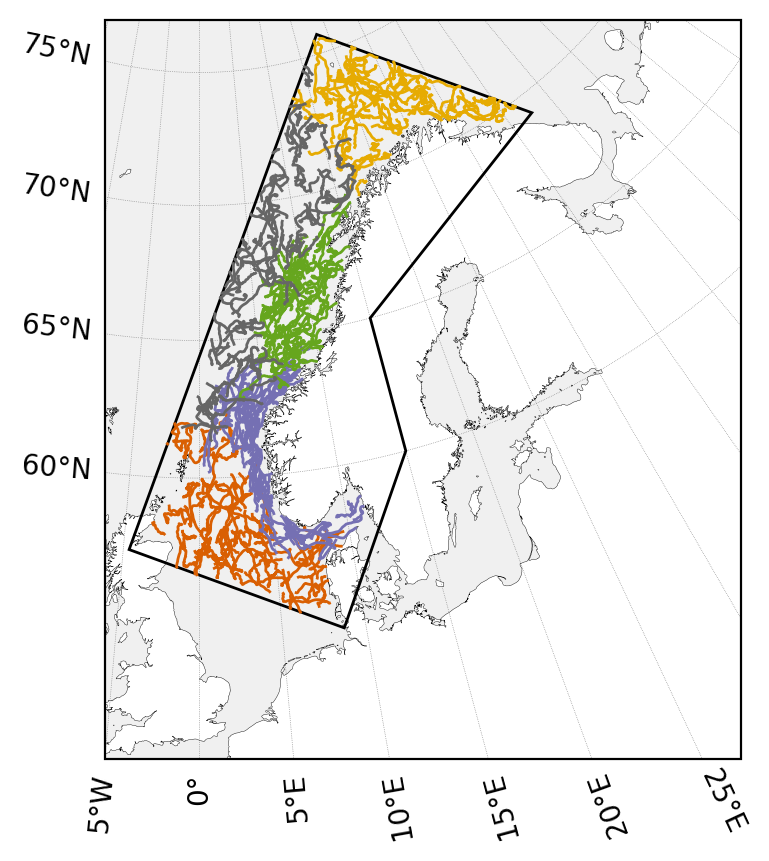

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import cartopy.crs as ccrs # Geospatial data processing
import cartopy.feature as cfeature # Features (land, boundaries) from cartopy
import glob

models = ['topaz6', 'topaz5', 'norkyst']
regions = [2,3,4,5,6]
path_outputs = '/lustre/storeB/users/victorm/foccus_subtask_713/runs/'


# ------------------------------------------------------ #
# --- Let's plot the simulations forced with Norkyst --- #
# ------------------------------------------------------ #

lon_nk = [-4.61489652, 18.32942509, 37.55453838, 15, 15, 8.69997235, -4.61489652]
lat_nk = [57.34412441, 75.72596758, 69.24523963, 65, 60, 54.29489733,57.34412441]

# Define Cartopy object
projection = ccrs.Stereographic(central_latitude=90, central_longitude=0, \
    false_easting=0, false_northing=0, true_scale_latitude=75, globe=None)


cmap = plt.get_cmap("Dark2", 7)
bounds = np.arange(1, 7 + 1, 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)


fig = plt.figure(dpi=200)
ax = plt.axes(projection=projection)

transform = ccrs.PlateCarree()._as_mpl_transform(ax)

for R in regions:
    dof = glob.glob(path_outputs + models[2] + '/' + 'region%s/'%(str(R)) + '*.nc')
    
    # Open files here:
    for F in dof:
        df = xr.open_dataset(F, engine='netcdf4')
        lon = df.lon[0,:]
        lat = df.lat[0,:]
        
        ax.plot(lon, lat, c=cmap(norm(R)), lw=1, zorder=1e4, transform=ccrs.PlateCarree())
        
### Plot some other stuff
zipped_bep = zip(lon_nk, lat_nk)
poly_beps = mpatches.Polygon(list(zipped_bep), closed=True,\
                        facecolor='none', edgecolor='black', lw=1, transform=ccrs.Geodetic(), zorder=2005) # it has to be clockwise, LLC first
ax.add_patch(poly_beps)


### Add color, land etc ###
ax.add_feature(cfeature.LAKES, facecolor=("white"))
ax.add_feature(cfeature.OCEAN, facecolor=("#f0f0f0"))
ax.coastlines(resolution='10m', color='black', linewidth=.15, zorder=2002)

# Set extent

ax.set_extent([-5, 30, 50, 75], crs=ccrs.PlateCarree())

# Adjust grid labels
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='gray', linestyle='dotted', linewidth=0.25, draw_labels=True,\
     dms=True, x_inline=False, y_inline=False, alpha=1, zorder=2003) # Display lat/lon grid

gl.top_labels = False
gl.bottom_labels =True
gl.left_labels = True
gl.right_labels = False

gl.ylocator = mticker.FixedLocator(np.arange(60, 95, 5))
gl.xlocator = mticker.FixedLocator(np.arange(-180, 180, 5))

plt.show()


#### Assessment

- Here we use the rotary spectral analysis to evaluate the models;
- We will check for Norkyst V3 x TOPAZ5, for all the five ROIs;

Text(0, 0.5, 'Energy density [m$^{2}$ s$^{-2}$ cph$^{-1}$]')

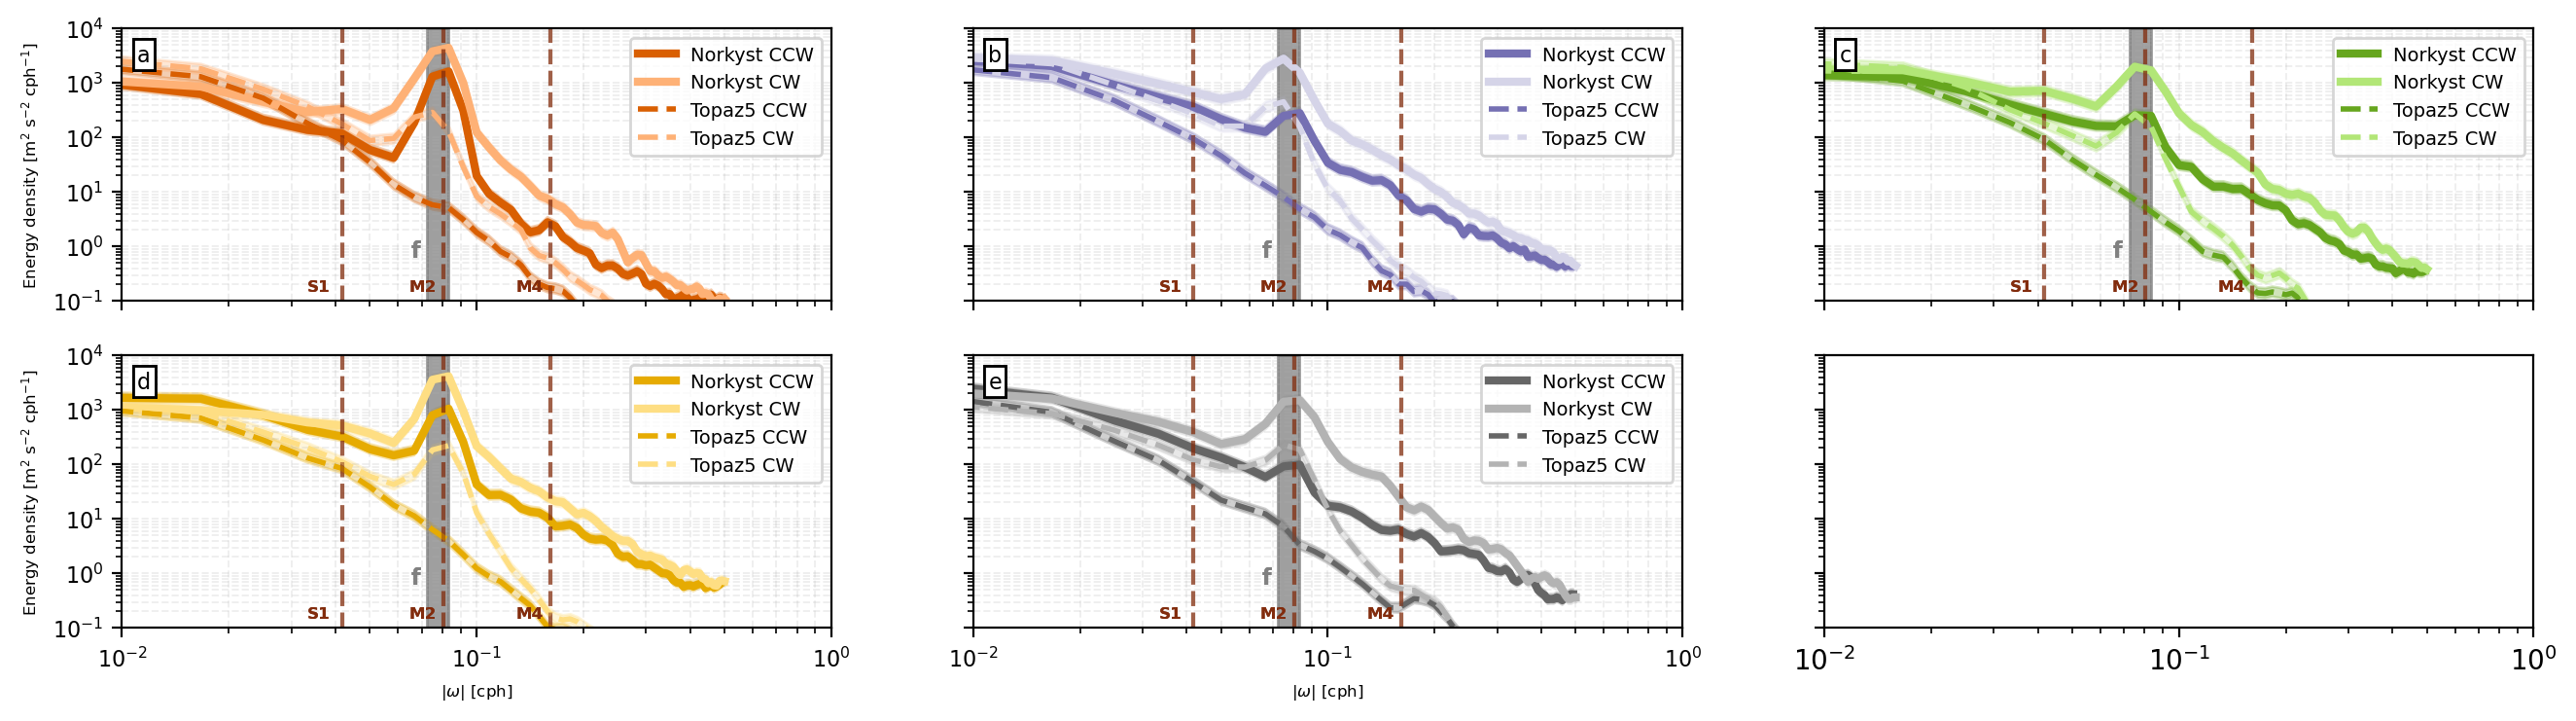

In [3]:
import warnings
import colorsys
from scipy.signal import get_window
import scipy as sp
import scipy.stats as stats 
import scipy.signal as signal
import scipy.fftpack as fftpack
import matplotlib.offsetbox as offsetbox
from scipy.stats import chi2

warnings.filterwarnings("ignore")


def plot_image_index(ax, index):
    index_obj = offsetbox.AnchoredText(str(index), loc=2, prop=dict(color='k', size=8), pad=0.2)
    index_obj.set_zorder(1000)
    index_obj.patch.set(alpha=1)
    ax.add_artist(index_obj)

def make_plot(fpos, fneg, pccwo, pcwo, ax, model, c1, c2, ls, lw, label):
    ax.plot(fpos/cph, np.nanmean(pccwo, axis=0), color=c1, linestyle=ls, lw=lw, label=model+ ' ' + 'CCW')
    ax.plot(fneg/cph, np.nanmean(pcwo, axis=0), color=c2, linestyle=ls, lw=lw, label=model+ ' ' + 'CW')
    
    ### Define confidence interval for model
    
    ccwo_lower, ccwo_upper = ci_spectral(pccwo)
    cwo_lower, cwo_upper = ci_spectral(pcwo)
    
    ax.fill_between(fpos/cph, ccwo_lower, ccwo_upper, facecolor=c1, edgecolor=c1, alpha=0.3)
    ax.fill_between(fneg/cph, cwo_lower, cwo_upper, facecolor=c2, edgecolor=c2, alpha=0.3)
    
    # Set other things for the plot
    # Define axis limits and scales
    ax.set_yscale('log')
    ax.set_xscale('log')
    
    ax.set_xlim([1e-2, 1e0])
    ax.set_ylim([1e-1, 1e4])
    
    ax.grid(True, which="both", ls="--", lw=0.7, alpha=0.2)
    
    # Define key frequencies
    
    s1 = (1/(24*3600))/cph
    m2 = (1/(12.42*3600))/cph
    m4 = (1/(6.2103*3600))/cph
    
    # Define color for texts and dashed lines
    Color = '#822C0D' #'#AA353F'
    xcoords = [s1, m2, m4]
    for xc in xcoords:
        ax.axvline(x=xc, c=Color, ls='--', alpha = 0.5)
        
    # Set text
    ypos = 1.5e-1
    ax.text(s1-s1/5, ypos, 'S1', color=Color, weight='bold', size=6)
    ax.text(m2-m2/5, ypos, 'M2', color=Color, weight='bold', size=6)
    ax.text(m4-m4/5, ypos, 'M4', color=Color, weight='bold', size=6)
    
    # Calculate inertial period
    f_values = np.arange(60, 85, 0.5)
    omega = 7.2921*1e-5
    
    f = 2*omega*np.sin(np.deg2rad(f_values))
    T = (2*np.pi)/f
    
    # Plot the region
    f0 = (1/((T[0]/3600)*3600))/cph
    f1 = (1/((T[-1]/3600)*3600))/cph
    ax.axvspan(f0, f1, alpha=0.5, color='gray')
    
    # Set text for f
    ax.text(f0-f0/10, ypos+0.5, 'f', color='gray', size=8, weight='bold')
    
    # Organize labels
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=7)

    # Organize tick labels
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    
    # Define caption for the subplots
    plot_image_index(ax, label)

    return ax

def rotaryspectra(x, dt, rescale):
    '''
    This is a function provided by JR
    '''
    #window = signal.blackman(nperseg)    
    nperseg = x.shape[1]
    M = x.shape[0]
    N = M*nperseg
    Yw = fftpack.fft(x, n=nperseg) * dt * rescale # discrete fourier transform, rescale fft by constant if a window was applied.
    #Gww = 2/(N*dt) * (Yw.conj()*Yw).sum(axis=0) # spectral density function as defined in Emery and Thomson 1997, pp. 427 in 
    Gww = 1/(N*dt) * (Yw.conj()*Yw).sum(axis=0) # same, but for two-sided spectra
    #Gww = 1. / dt * (Yw.conj()*Yw).mean(axis=0) 
    f = np.fft.fftfreq(nperseg,dt) # equiv. to f = sp.arange(nperseg/2.)/(nperseg * dt) but with shifted frequencies

    crop = int(nperseg/2)
    Scc = Gww[:crop] #counterclockwise spectrum
    Scl = Gww[crop:] #clockwise spectrum
    fpos = f[:crop]
    fneg = -f[crop:]

    return Scc, Scl, fpos, fneg,f

def ci_spectral(power):
    alpha = 0.05  # 95% confidence
    
    Nreal = power.shape[0]
    nu = 2 * Nreal
    
    Smean = np.nanmean(power, axis=0)
    
    chi2_low  = chi2.ppf(1 - alpha/2, nu)
    chi2_high = chi2.ppf(alpha/2, nu)
    
    S_lower = (nu / chi2_low) * Smean
    S_upper = (nu / chi2_high) * Smean

    return (S_lower, S_upper)

# ----------------------------
# Helper: shift lightness / saturation without changing hue
# ----------------------------
def adjust_lightness(color, amount=0.1):
    """
    Adjust lightness of an RGBA color in HLS space.
    amount > 0: lighter, <0: darker
    """
    r, g, b, a = color
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l_new = max(0, min(1, l + amount))
    r_new, g_new, b_new = colorsys.hls_to_rgb(h, l_new, s)
    return (r_new, g_new, b_new, a)



###########################################
### We begin working with the data here ###
###########################################

models = ['norkyst', 'topaz5']

# ----------------------------------- #
# --- Define colors as in the map --- #
# ----------------------------------- #
cmap = plt.get_cmap("Dark2", 7)
bounds = np.arange(1, 7 + 1, 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# ----------------------------- #
# --- Define some arguments --- #
# ----------------------------- #
nperseg = 120 # 5 days
cph = 0.000277777777777778
w = get_window('blackman', nperseg)

# ------------------------------------- #
# --- Check number of 'valid' files --- #
# ------------------------------------- #
#fig, (ax1, ax2) = plt.subplots(2, 3, figsize=(16, 4), dpi=200)

fig, axs = plt.subplots(2, 3, figsize=(16, 4), dpi=200, sharey=True, sharex=True)
axs = axs.flatten()  # flatten to 1D array: [ax1, ax2, ax3, ax4, ax5, ax6]

labels = ['a', 'b', 'c', 'd', 'e']
regions_spect = [2, 3, 4, 5, 6]  # example mapping

reg_dic = {region: (ax, lbl) for region, ax, lbl in zip(regions_spect, axs, labels)}

for region in regions_spect:
    # Slightly change color for CCW and CW
    base_color = cmap(norm(region))
    lighter_color = adjust_lightness(base_color, amount=.30)

    '''
    if region == 3:
        ax = ax1
        label = 'a'
        
    if region == 5:
        ax = ax2
        label = 'b'
    '''
    ax, label = reg_dic[region]
    
    for model in models:
        if model == 'topaz5':
            ls = '--'
            lw = 2
        if model == 'norkyst':
            ls = '-'
            lw = 3
            
        dof = glob.glob(path_outputs + model + '/' + 'region%s/'%(str(region)) + '*.nc')
        
        available_files = []
        for f in dof:
            df = xr.open_dataset(f, engine='netcdf4')[['time']]
        
            if len(df.time) < 120:
                continue
            else:
                available_files.append(f)
    
        # -------------------------- #
        # --- Create save matrix --- #
        # -------------------------- #
        
        FNEG = np.ones((len(available_files),60))*np.nan
        FPOS = np.ones((len(available_files),60))*np.nan
        PCWO = np.zeros((len(available_files), 60))*np.nan
        PCCWO = np.zeros((len(available_files), 60))*np.nan
        
        # ------------------------------------ #
        # --- We work here on the datasets --- #
        # ------------------------------------ #
        
        index = 0
        for F in available_files:
            df = xr.open_dataset(F, engine='netcdf4')
            
            df.isel(trajectory=0)
            
            uop, vop = df.x_sea_water_velocity.isel(time=slice(0, 120)).values, df.y_sea_water_velocity.isel(time=slice(0, 120)).values

            UO = (uop - uop.mean(axis=1, keepdims=True))*w
            VO = (vop - vop.mean(axis=1, keepdims=True))*w
        
            rescale = np.sqrt(1.0 / np.mean(w**2))
            
            scco, sclo, fpos, fneg, fo = rotaryspectra(UO+1j*VO, 3600, rescale)
        
            # Store values in the matrices
            FPOS[index,:] = fpos
            FNEG[index,:] = fneg
            PCWO[index,:] = sclo
            PCCWO[index,:] = scco
        
            index += 1
    
        make_plot(FPOS[0], FNEG[0], PCCWO, PCWO, ax, model.capitalize(), base_color, lighter_color, ls, lw, label)


###################################
### Organize y- and xlabel here ###
###################################

# Fix labels
axs[3].set_xlabel(r'|$\omega$| [cph]', fontsize=6)
axs[4].set_xlabel(r'|$\omega$| [cph]', fontsize=6)
axs[3].set_ylabel(r'Energy density [m$^{2}$ s$^{-2}$ cph$^{-1}$]', fontsize=6)
axs[0].set_ylabel(r'Energy density [m$^{2}$ s$^{-2}$ cph$^{-1}$]', fontsize=6)

Here I try to replicate the results using the function I've tried to implement.

**Q**: The spectra obtained with *gonella_rotary_spectra* has less energy then the ones estimated with *spec_rot*. Why so? Maybe my scaling is wrong?

Text(0, 0.5, 'Energy density [m$^{2}$ s$^{-2}$ cph$^{-1}$]')

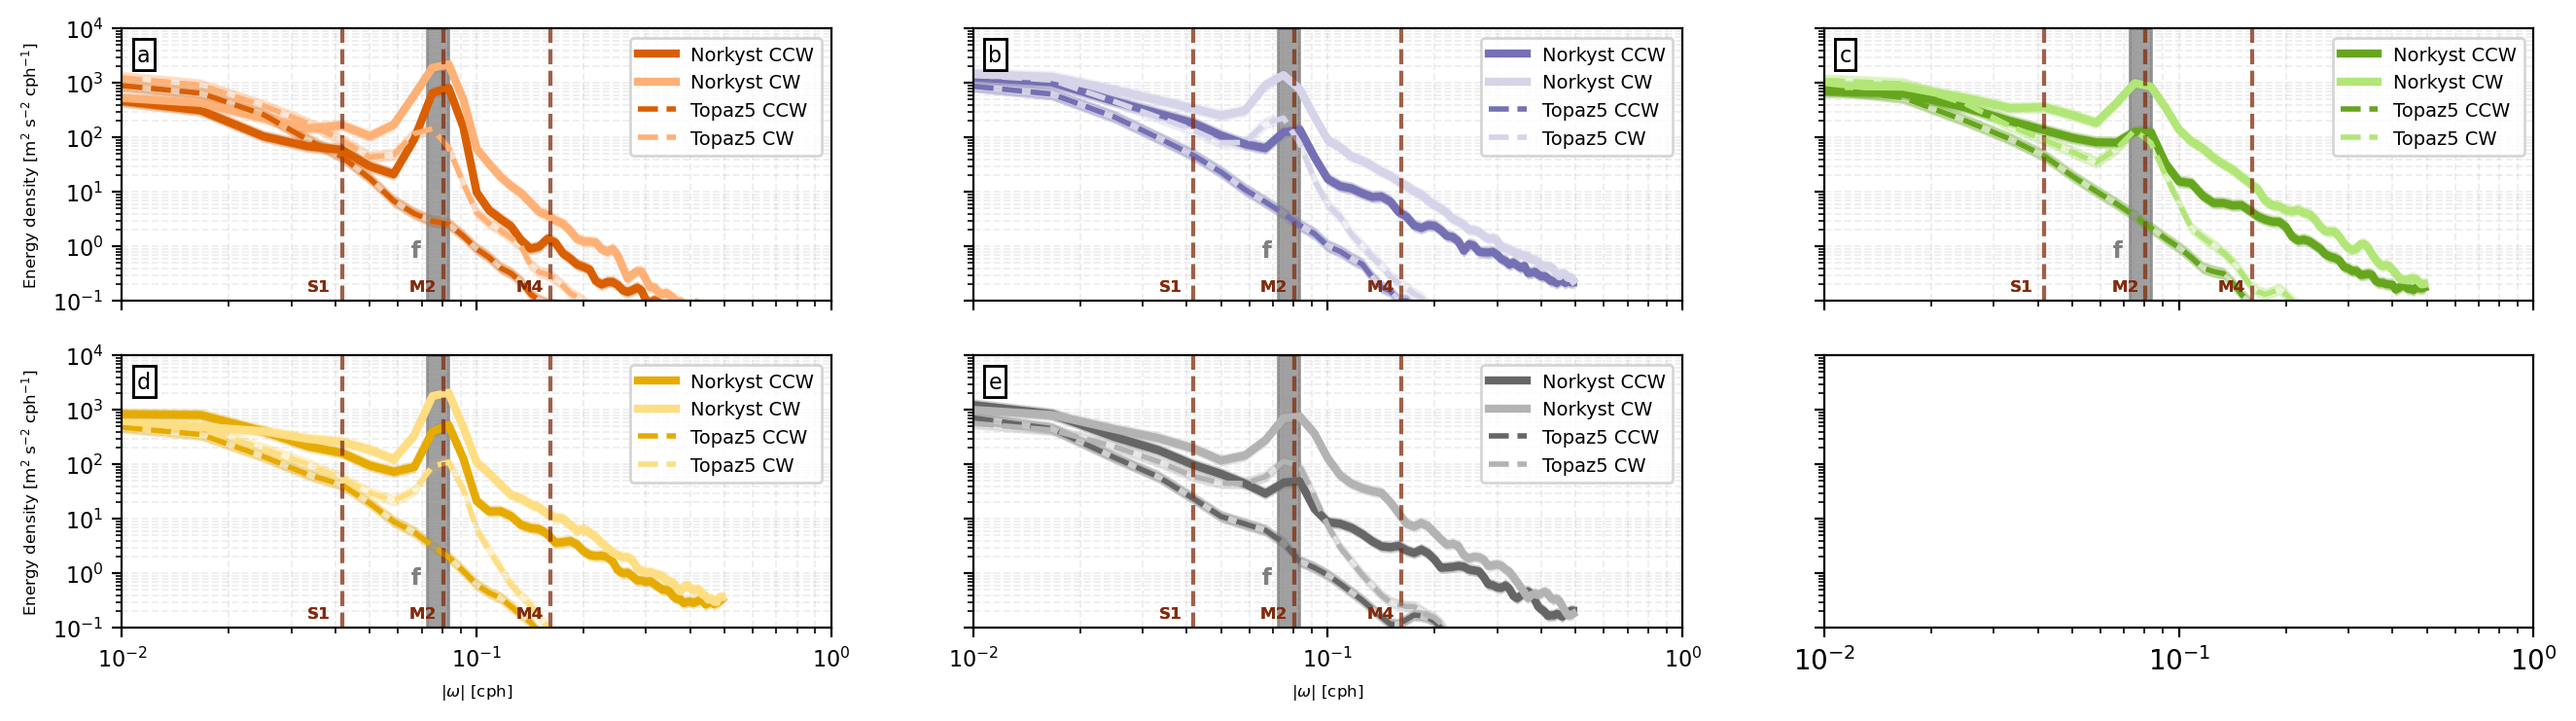

In [9]:
def gonella_rotary_spectra(u, v, dt, nperseg=None, noverlap=None, window='blackman'):
    """
    Compute Gonella (1973) rotary spectra with windowing, segmentation, and scaling
    to match FFT-based magnitude conventions. Returns S+, S-, total spectrum, and rotary coefficient.

    Parameters
    ----------
    u, v : 1D arrays
        Velocity components (same length)
    dt : float
        Sampling interval in seconds
    nperseg : int, optional
        Segment length (default: full series)
    noverlap : int, optional
        Overlap between segments (default: 0)
    window : str
        Window type from scipy.signal.get_window

    Returns
    -------
    fpos : positive frequencies
    S_plus : counterclockwise spectrum
    S_minus : clockwise spectrum
    St : total spectrum (S_plus + S_minus)
    CR : rotary coefficient ((S_minus - S_plus)/St)
    """
    u = np.asarray(u).squeeze()
    v = np.asarray(v).squeeze()
    
    N = len(u)
    
    # Default to full series if no segmentation
    if nperseg is None:
        nperseg = N
    if noverlap is None:
        noverlap = 0
    
    step = nperseg - noverlap
    segments = []
    
    # Slice series into overlapping segments
    for start in range(0, N - nperseg + 1, step):
        segments.append((u[start:start+nperseg], v[start:start+nperseg]))
    
    M = len(segments)
    
    Scc_list = []
    Scw_list = []
    
    for seg_u, seg_v in segments:
        # Remove mean
        seg_u = seg_u - seg_u.mean()
        seg_v = seg_v - seg_v.mean()
        
        # Apply window
        w = get_window(window, nperseg)
        seg_u *= w
        seg_v *= w
        
        # Window power correction
        Uw = np.mean(w**2)
        
        # FFT
        U = np.fft.fft(seg_u)
        V = np.fft.fft(seg_v)
        
        # Autospectra scaling
        Puu = (dt / (nperseg * Uw)) * (U * U.conj())
        Pvv = (dt / (nperseg * Uw)) * (V * V.conj())
        
        # Cross-spectrum
        Puv = (dt / (nperseg * Uw)) * (U * V.conj())
        Quv = np.imag(Puv)
        
        # Rotary spectra
        S_plus = 0.5 * (Puu + Pvv + 2 * Quv)    # CCW
        S_minus = 0.5 * (Puu + Pvv - 2 * Quv)   # CW
        
        Scc_list.append(S_plus)
        Scw_list.append(S_minus)
    
    # Average over segments
    S_plus = np.mean(Scc_list, axis=0).real
    S_minus = np.mean(Scw_list, axis=0).real
    
    # Total spectrum
    St = S_plus + S_minus
    
    # Rotary coefficient
    CR = (S_minus - S_plus) / St
    
    # Frequency vector
    f = np.fft.fftfreq(nperseg, dt)
    pos = f > 0
    fpos = f[pos]
    
    return fpos, S_plus[pos], S_minus[pos], St[pos], CR[pos]

# ------------------------------------------ #
# --- Try the same, but with my function --- #
# ------------------------------------------ #

fig, axs = plt.subplots(2, 3, figsize=(16, 4), dpi=200, sharey=True, sharex=True)
axs = axs.flatten()  # flatten to 1D array: [ax1, ax2, ax3, ax4, ax5, ax6]

labels = ['a', 'b', 'c', 'd', 'e']
regions_spect = [2, 3, 4, 5, 6] # example mapping

reg_dic = {region: (ax, lbl) for region, ax, lbl in zip(regions_spect, axs, labels)}

for region in regions_spect:
    # Slightly change color for CCW and CW
    base_color = cmap(norm(region))
    lighter_color = adjust_lightness(base_color, amount=.30)

    '''
    if region == 3:
        ax = ax1
        label = 'a'
        
    if region == 5:
        ax = ax2
        label = 'b'
    '''
    ax, label = reg_dic[region]
    
    for model in models:
        if model == 'topaz5':
            ls = '--'
            lw = 2
        if model == 'norkyst':
            ls = '-'
            lw = 3
            
        dof = glob.glob(path_outputs + model + '/' + 'region%s/'%(str(region)) + '*.nc')
        
        available_files = []
        for f in dof:
            df = xr.open_dataset(f, engine='netcdf4')[['time']]
        
            if len(df.time) < 120:
                continue
            else:
                available_files.append(f)
    
        # -------------------------- #
        # --- Create save matrix --- #
        # -------------------------- #
        
        FNEG = np.ones((len(available_files),59))*np.nan
        FPOS = np.ones((len(available_files),59))*np.nan
        PCWO = np.zeros((len(available_files), 59))*np.nan
        PCCWO = np.zeros((len(available_files), 59))*np.nan
        
        # ------------------------------------ #
        # --- We work here on the datasets --- #
        # ------------------------------------ #
        
        index = 0
        for F in available_files:
            df = xr.open_dataset(F, engine='netcdf4')
            
            df.isel(trajectory=0)
            
            uop, vop = df.x_sea_water_velocity.isel(time=slice(0, 120)).values, df.y_sea_water_velocity.isel(time=slice(0, 120)).values

            f, S_plus, S_minus, St, CR = gonella_rotary_spectra(uop, vop, 3600, nperseg=120, noverlap=0, window='blackman')

            # Store values in the matrices
            FPOS[index,:] = f
            FNEG[index,:] = f
            PCWO[index,:] = S_minus
            PCCWO[index,:] = S_plus
        
            index += 1
    
        make_plot(FPOS[0], FNEG[0], PCCWO, PCWO, ax, model.capitalize(), base_color, lighter_color, ls, lw, label)


###################################
### Organize y- and xlabel here ###
###################################

# Fix labels
axs[3].set_xlabel(r'|$\omega$| [cph]', fontsize=6)
axs[4].set_xlabel(r'|$\omega$| [cph]', fontsize=6)
axs[3].set_ylabel(r'Energy density [m$^{2}$ s$^{-2}$ cph$^{-1}$]', fontsize=6)
axs[0].set_ylabel(r'Energy density [m$^{2}$ s$^{-2}$ cph$^{-1}$]', fontsize=6)